# **Import Libraries**

# Table of Contents
- [Import Libraries](#Import-Libraries)
- [Load and Visualize Data](#Load-and-Visualize-Data)
- [Feature Engineering](#Feature-Engineering)
- [Define Pipeline for Feature Engineering, Preprocessing and model training](#Define-Pipeline-for-Feature-Engineering,-Preprocessing-and-model-training)
- [RFC Model](#RFC-Model)
- [XGBoost Model](#XGBoost-Model)
- [Model Comparison](#Model-Comparison)
- [Conclusions](#Conclusions)

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random

random.seed(42)
np.random.seed(42)

import sklearn
from sklearn import __version__ as sklearn_version

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, f1_score,
                             precision_recall_curve, roc_curve,
                             auc, precision_score, recall_score,
                             RocCurveDisplay, PrecisionRecallDisplay)

print('versions: sklearn', sklearn_version,
      'xgboost', xgb.__version__,
      'pandas', pd.__version__,
      'numpy', np.__version__)


versions: sklearn 1.6.1 xgboost 3.2.0 pandas 2.2.2 numpy 2.0.2


# **Load and Visualize Data**

In [2]:
# Load the specific CSV file from the dataset

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "uciml/adult-census-income",
  "adult.csv",
)

# normalize the key column naming style (snake_case)
df = df.rename(columns={
    'hours.per.week': 'hours_per_week_raw',
    'capital.gain': 'capital_gain',
    'capital.loss': 'capital_loss',
    'native.country': 'native_country',
    'education.num': 'education_num',
    'marital.status': 'marital_status'
})

df.head()

Using Colab cache for faster access to the 'adult-census-income' dataset.


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week_raw,native_country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df.shape

(32561, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   age                 32561 non-null  int64 
 1   workclass           32561 non-null  object
 2   fnlwgt              32561 non-null  int64 
 3   education           32561 non-null  object
 4   education_num       32561 non-null  int64 
 5   marital_status      32561 non-null  object
 6   occupation          32561 non-null  object
 7   relationship        32561 non-null  object
 8   race                32561 non-null  object
 9   sex                 32561 non-null  object
 10  capital_gain        32561 non-null  int64 
 11  capital_loss        32561 non-null  int64 
 12  hours_per_week_raw  32561 non-null  int64 
 13  native_country      32561 non-null  object
 14  income              32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
#Replace question marks with null values

df[df == '?'] = np.nan

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   age                 32561 non-null  int64 
 1   workclass           30725 non-null  object
 2   fnlwgt              32561 non-null  int64 
 3   education           32561 non-null  object
 4   education_num       32561 non-null  int64 
 5   marital_status      32561 non-null  object
 6   occupation          30718 non-null  object
 7   relationship        32561 non-null  object
 8   race                32561 non-null  object
 9   sex                 32561 non-null  object
 10  capital_gain        32561 non-null  int64 
 11  capital_loss        32561 non-null  int64 
 12  hours_per_week_raw  32561 non-null  int64 
 13  native_country      31978 non-null  object
 14  income              32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
# Replace the null values with the mode of each column

for col in ['workclass', 'occupation', 'native_country']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [9]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week_raw
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [10]:
#Mapping binary values to the expected output

df['income']=df['income'].map({'<=50K': 0, '>50K': 1})

# **Feature Engineering**

## **Comparison of feature distributions**

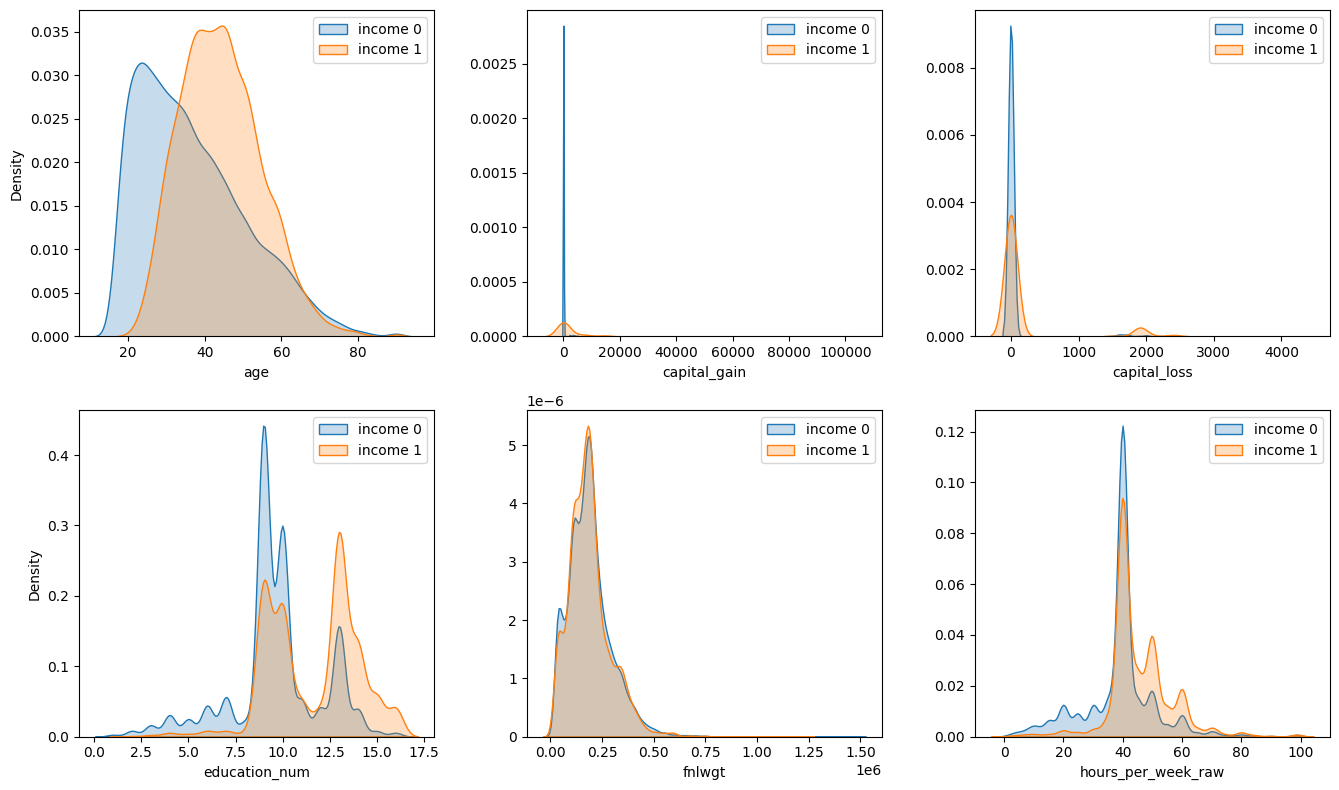

In [11]:
df_0, df_1 = df[df['income'] == 0], df[df['income'] == 1]
numeric_features = df.select_dtypes(include=['number']).columns
features = numeric_features.difference(['income'])
cols, ncols = list(features), 3
nrows = math.ceil(len(cols) / ncols)

fig, ax = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))

axes = ax.flatten()

for i, col in enumerate(cols):
    sns.kdeplot(df_0[col], ax=axes[i], label='income 0', fill=True)
    sns.kdeplot(df_1[col], ax=axes[i], label='income 1', fill=True)

    if i % ncols != 0:
        axes[i].set_ylabel(" ")
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## **Correlation heatmap for numerical features**

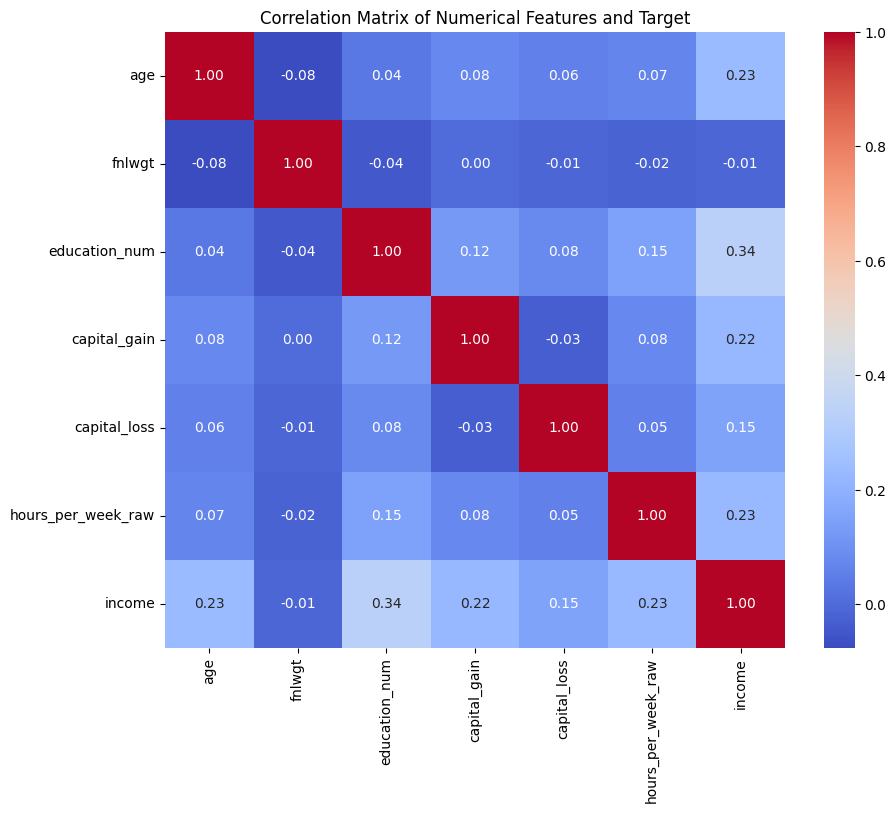

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features and Target')
plt.show()

In [13]:
# fnlwgt feature has low correlation with income nearing zero so we wwill drop it
df = df.drop(['fnlwgt'], axis = 1)

In [14]:
df_eda = df.copy()

/tmp/ipykernel_59065/1801060948.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Chi2_Stat', y='Feature', palette='viridis')


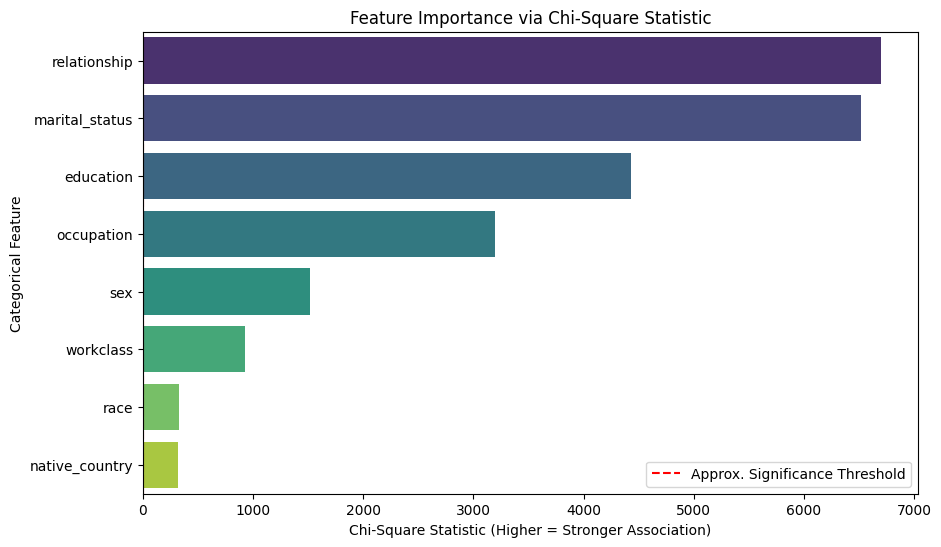

In [15]:
# Statistical Tests
from scipy.stats import chi2_contingency

# Chi-square test for categorical features vs income
cat_features = df_eda.select_dtypes(exclude=['number']).columns
results = []
for col in cat_features:
    contingency_table = pd.crosstab(df_eda[col], df_eda['income'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    results.append({'Feature': col, 'p-value': p, 'Chi2_Stat': chi2})

# 2. Create a results DataFrame
df_results = pd.DataFrame(results).sort_values('Chi2_Stat', ascending=False)

# 3. Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='Chi2_Stat', y='Feature', palette='viridis')
plt.axvline(x=3.84, color='red', linestyle='--', label='Approx. Significance Threshold') # Chi2 crit for df=1
plt.title('Feature Importance via Chi-Square Statistic')
plt.xlabel('Chi-Square Statistic (Higher = Stronger Association)')
plt.ylabel('Categorical Feature')
plt.legend()
plt.show()

## **Combine Capital Gain and Capital Loss Features**

In [16]:
# Capital gain and capital loss can be combined into capital net

df_eda['capital_net'] = df_eda['capital_gain'] - df_eda['capital_loss']
df_eda = df_eda.drop(['capital_gain', 'capital_loss'], axis=1)

<Axes: xlabel='capital_net', ylabel='Count'>

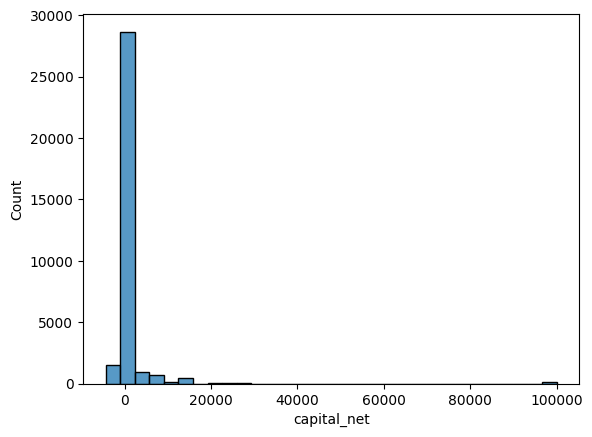

In [17]:
bins_df = math.floor(len(df_eda) ** (1/3))
sns.histplot(data=df_eda, x='capital_net', bins=bins_df)

<Axes: xlabel='income', ylabel='count'>

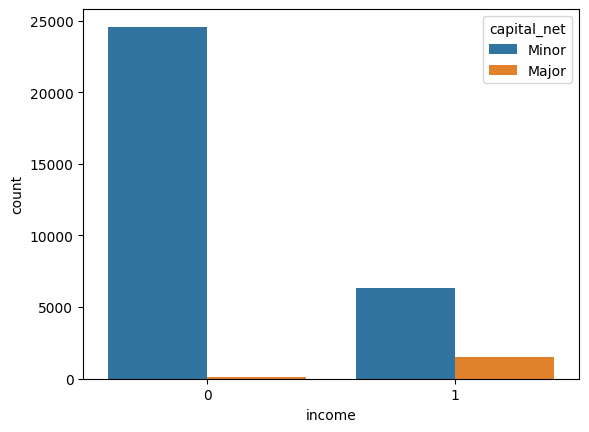

In [18]:
df_eda['capital_net'] = pd.cut(df_eda['capital_net'], bins=[-5000, 5000, 100000], labels=['Minor', 'Major']).astype(str)
sns.countplot(x='income', hue='capital_net', data=df_eda)

## **Categorize Age Feature into 3 Classes**

In [19]:
df_eda['age'] = pd.cut(df_eda['age'], bins=[0, 25, 50, 100], labels=['Young', 'Adult', 'Old']).astype(str)

<Axes: xlabel='income', ylabel='count'>

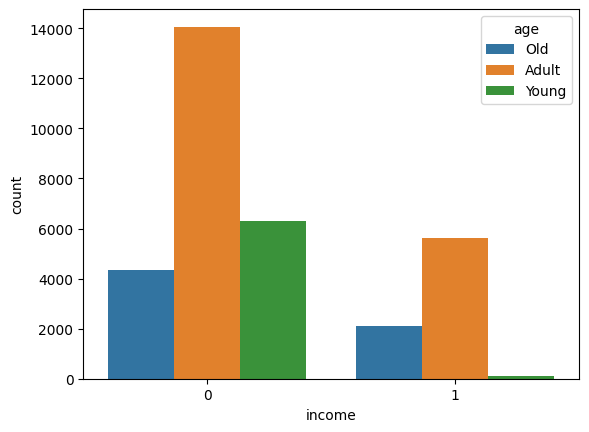

In [20]:
sns.countplot(x='income', hue='age', data=df_eda)

## **Count Plot for Categorical Features**

In [21]:
def plot_categorical_countplots(df, cat_cols, target_col='income', ncols=3):
    """
    Plot countplots for categorical columns vs target.

    Args:
        df (pd.DataFrame): Dataframe containing data.
        cat_cols (list): List of categorical column names.
        target_col (str): Target column name.
        ncols (int): Number of columns in subplot grid.
    """
    cols = list(cat_cols)
    nrows = math.ceil(len(cols) / ncols)

    # Setup figure and axes
    fig, ax = plt.subplots(nrows, ncols, figsize=(10 * ncols, 10 * nrows))

    # Flatten axes array for easy iteration, handles case where nrows=1
    axes = ax.flatten() if nrows > 1 else [ax]

    # Loop through columns and plot
    for i, col in enumerate(cols):
        sns.countplot(x=target_col, hue=col, data=df, ax=axes[i])
        axes[i].set_title(f'{target_col.capitalize()} by {col}')

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

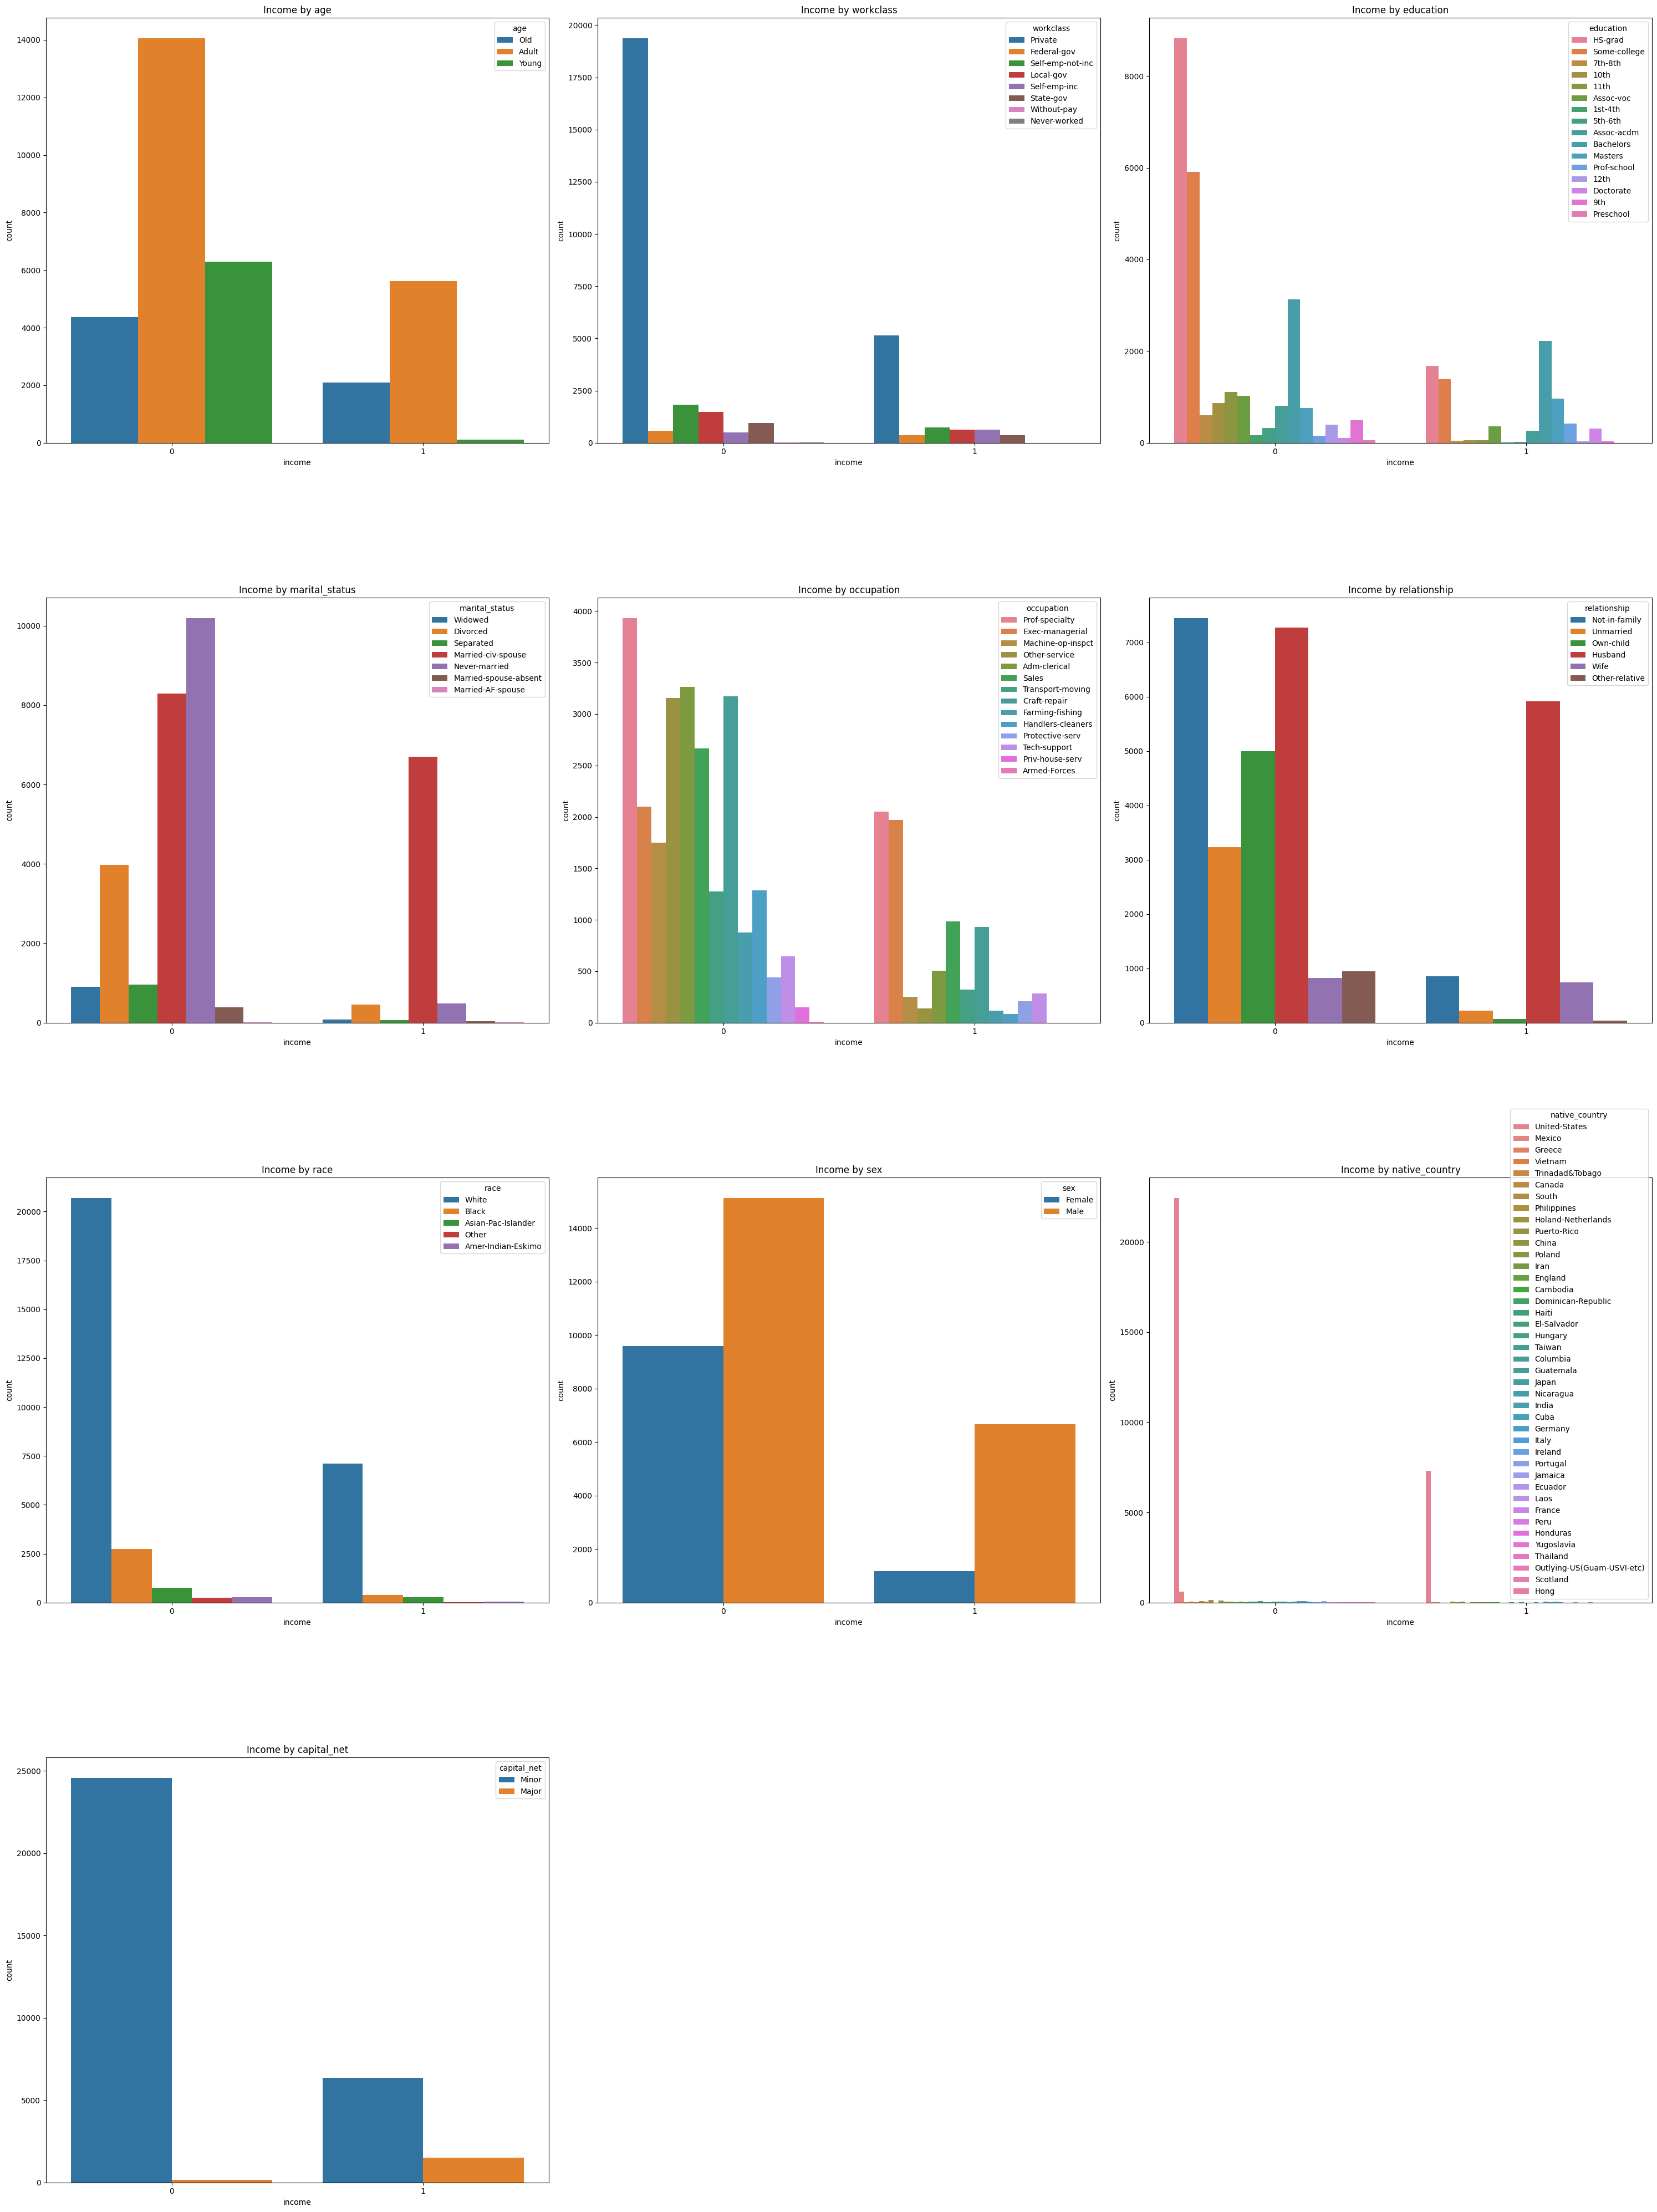

In [22]:
# 1. Identify categorical columns
cat_col = df_eda.select_dtypes(exclude=['number']).columns

# 2. Plot using the helper function
plot_categorical_countplots(df_eda, cat_col)

## **Combining Lower Grades of Education into One Class**

In [23]:
#Combining the lower grades of education together

df_eda['education'] = df_eda['education'].replace(['11th', '9th', '7th-8th', '5th-6th', '10th', '1st-4th', 'Preschool', '12th'], 'School')
df_eda['education'].value_counts()

,count
education,
HS-grad,10501
Some-college,7291
Bachelors,5355
School,4253
Masters,1723
Assoc-voc,1382
Assoc-acdm,1067
Prof-school,576
Doctorate,413


<Axes: xlabel='income', ylabel='count'>

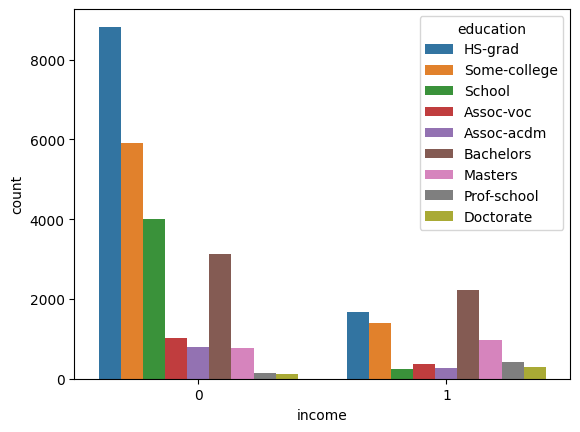

In [24]:
sns.countplot(x='income', hue='education', data=df_eda)

## **Categorize hours.per.week Feature into 3 Classes**

In [25]:
df_eda['hours_per_week'] = pd.cut(df_eda['hours_per_week_raw'],
                                   bins=[0, 30, 40, 100],
                                   labels=['Lesser Hours', 'Normal Hours', 'Extra Hours']).astype(str)
df_eda = df_eda.drop(['hours_per_week_raw'], axis=1)

<Axes: xlabel='income', ylabel='count'>

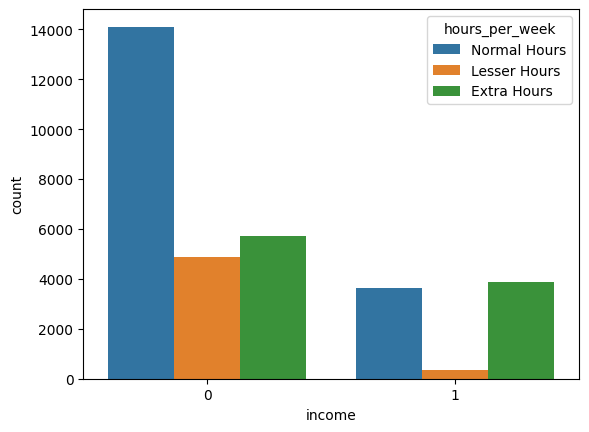

In [26]:
sns.countplot(x='income', hue='hours_per_week', data=df_eda)

## **Combine races in race feature other than white into one class**

In [27]:
#Since majority of race is white, the rest of races can be combined together to a single class

df_eda['race'].unique()
df_eda['race'] = df_eda['race'].replace(['Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo', 'Other'], 'Other')

<Axes: xlabel='income', ylabel='count'>

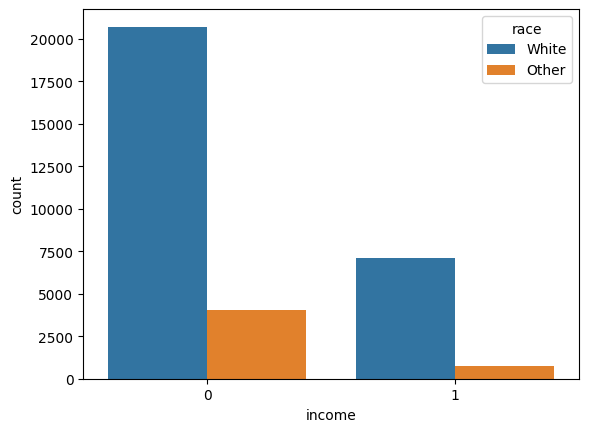

In [28]:
sns.countplot(x='income', hue='race', data=df_eda)

## **Combine countries in native.country feature other than United-States into one class**

In [29]:
countries = np.array(df_eda['native_country'].unique())
countries = np.delete(countries, 0)
df_eda['native_country'] = df_eda['native_country'].replace(countries, 'Other')

<Axes: xlabel='native_country', ylabel='count'>

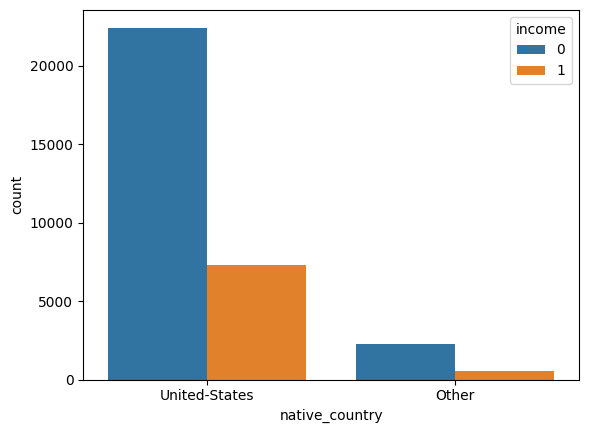

In [30]:
sns.countplot(x='native_country', hue='income', data=df_eda)

In [31]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  object
 1   workclass       32561 non-null  object
 2   education       32561 non-null  object
 3   education_num   32561 non-null  int64 
 4   marital_status  32561 non-null  object
 5   occupation      32561 non-null  object
 6   relationship    32561 non-null  object
 7   race            32561 non-null  object
 8   sex             32561 non-null  object
 9   native_country  32561 non-null  object
 10  income          32561 non-null  int64 
 11  capital_net     32561 non-null  object
 12  hours_per_week  32561 non-null  object
dtypes: int64(2), object(11)
memory usage: 3.2+ MB


<Axes: xlabel='income', ylabel='count'>

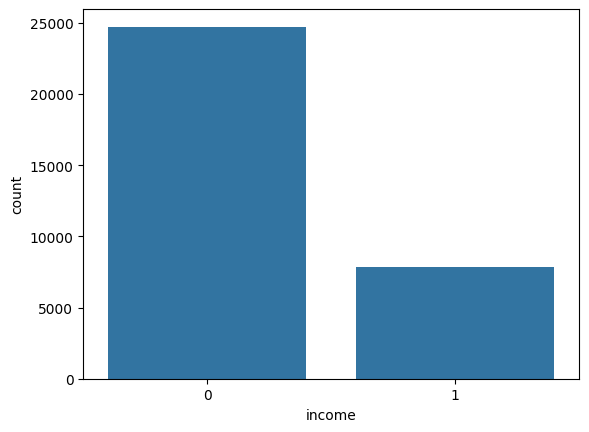

In [32]:
sns.countplot(x='income', data=df_eda)

# **Define Pipeline for Feature Engineering, Preprocessing, Imbalance Handling, and model training**

## **Define Feature Engineering Function**

In [33]:
def perform_feature_engineering(df):
    """
    Perform feature engineering on the dataset: binning, grouping, and cleanup.

    Args:
        df (pd.DataFrame): Input dataframe.

    Returns:
        pd.DataFrame: Transformed dataframe.
    """
    df = df.copy()

    # 1. Age Binning
    df['age'] = pd.cut(df['age'], bins=[0, 25, 50, 100],
                       labels=['Young', 'Adult', 'Old']).astype(str)

    # 2. Capital Net Calculation & Binning
    # We do the math first, then the binning
    df['capital_net'] = df['capital_gain'] - df['capital_loss']
    df['capital_net'] = pd.cut(df['capital_net'], bins=[-5000, 5000, 100000],
                               labels=['Minor', 'Major']).astype(str)

    # 3. Hours Per Week Binning
    df['hours_per_week'] = pd.cut(df['hours_per_week_raw'], bins=[0, 30, 40, 100],
                                     labels=['Lesser Hours', 'Normal Hours', 'Extra Hours']).astype(str)

    # 4. Race Grouping
    other_races = ['Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo', 'Other']
    df['race'] = df['race'].replace(other_races, 'Other')

    # 5. Education Grouping
    low_grades = ['11th', '9th', '7th-8th', '5th-6th', '10th', '1st-4th', 'Preschool', '12th']
    df['education'] = df['education'].replace(low_grades, 'School')

    # 6. THE PRO TIP: Native Country
    # Always keeps 'United-States', everything else becomes 'Other'
    df['native_country'] = df['native_country'].apply(lambda x: x if x == 'United-States' else 'Other')

    # 7. Final Column Cleanup
    cols_to_drop = ['capital_gain', 'capital_loss', 'hours_per_week_raw', 'education_num']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df

# Create the pipeline step
feature_transformer = FunctionTransformer(perform_feature_engineering)

## **Train-Test Split**

In [34]:
X = df.drop(['income'], axis = 1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [35]:
cat_col = X_train.select_dtypes(exclude=['number']).columns

bin_cols = ['sex', 'native_country', 'capital_net', 'race']

multi_cat_cols = cat_col.difference(bin_cols)

assert 'income' not in cat_col, "income should not be in features for preprocessing"


## **Define Feature Binarizer**

In [36]:
class FeatureBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self, mappings=None, unknown_value=0):
        self.mappings = mappings or {
            'sex': {'Male': 1, 'Female': 0},
            'native_country': {'United-States': 1, 'Other': 0},
            'capital_net': {'Minor': 1, 'Major': 0},
            'race': {'White': 1, 'Other': 0}
        }
        self.unknown_value = unknown_value

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X = X.copy()
        for col, mapping in self.mappings.items():
            if col in X.columns:
                # map known categories and set unknown values safely
                X[col] = X[col].map(lambda v: mapping.get(v, self.unknown_value))
                X[col] = X[col].fillna(self.unknown_value)
        return X

    def get_feature_names_out(self, input_features=None):
        return input_features

## **Pipeline for binary and multi-category Features**

In [37]:
bin_pipeline = Pipeline([
    ('binarizer', FeatureBinarizer())
])
multi_cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

## **Preprocessing using Column Transformer**

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ('bin', bin_pipeline, bin_cols),
        ('multi_cat', multi_cat_pipeline, multi_cat_cols)
    ]
)

# **RFC Model**

## **Define parameters for RFC model**

In [39]:
rfc_param_grid = {
    'clf__n_estimators': [100, 300],
    'clf__max_depth': [None, 15, 30],
    'clf__min_samples_split': [2, 10],
    'clf__min_samples_leaf': [1, 4],
    'clf__max_features': ['sqrt'],
    'clf__criterion': ['gini', 'entropy']
}

rfc_pipeline = ImbPipeline([
    ('custom_engineering', feature_transformer),
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.4, random_state=42)),
    ('clf', RandomForestClassifier(random_state=42))
])

In [40]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [41]:
rfc_grid_search = GridSearchCV(
    estimator=rfc_pipeline,
    param_grid=rfc_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

## **Model Training and Evaluation**

In [42]:
try:
    # Fit RandomForest via integrated transformation + resampling pipeline directly on raw training data
    rfc_grid_search.fit(X_train, y_train)

    print(f"Best Parameters: {rfc_grid_search.best_params_}")
    print(f"Best CV Score: {rfc_grid_search.best_score_}")

    best_rfc_model = rfc_grid_search.best_estimator_
except Exception as e:
    print(f"Error during training: {e}")
    best_rfc_model = None

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2, 'clf__n_estimators': 300}
Best CV Score: 0.8973130916029245


## **Plotting the importance of each feature in RFC Model**

<Axes: title={'center': 'Top 10 Feature Importances from Pipeline'}, ylabel='feature'>

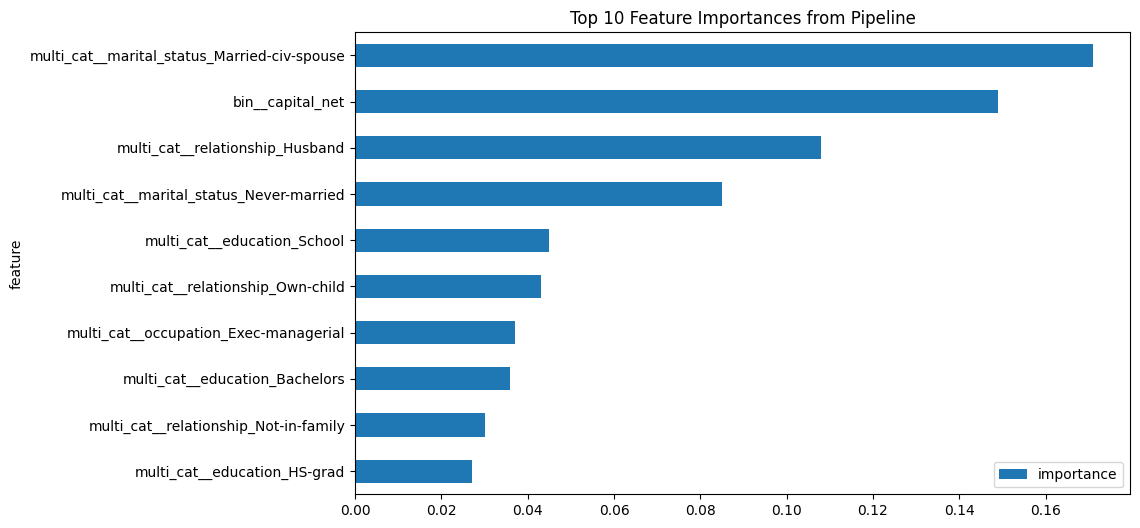

In [43]:
try:
    feature_names = best_rfc_model.named_steps['preprocessor'].get_feature_names_out()
except Exception:
    feature_names = [f'feature_{i}' for i in range(len(best_rfc_model.named_steps['clf'].feature_importances_))]

importances = pd.DataFrame({
    'feature': feature_names,
    'importance': np.round(best_rfc_model.named_steps['clf'].feature_importances_, 3)
})


top_10_importances = importances.sort_values('importance', ascending=False).head(10)

top_10_importances.sort_values('importance', ascending=True).set_index('feature').plot.barh(
    figsize=(10, 6),
    title="Top 10 Feature Importances from Pipeline"
)


## **RFC Classification Report**

In [44]:
y_pred_rfc = best_rfc_model.predict(X_test)
print(classification_report(y_test, y_pred_rfc))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4945
           1       0.70      0.61      0.65      1568

    accuracy                           0.84      6513
   macro avg       0.79      0.76      0.77      6513
weighted avg       0.84      0.84      0.84      6513



# **XGBoost Model**

## **Define parameters for XGB model**

In [51]:
xgb_param_grid = {
    'clf__n_estimators': [500, 700],
    'clf__learning_rate': [0.01, 0.05],
    'clf__max_depth': [3, 5],
    'clf__subsample': [0.7, 0.8],
    'clf__colsample_bytree': [0.7, 0.8],
    'clf__min_child_weight': [1, 2]
}

xgb_pipeline = ImbPipeline([
    ('custom_engineering', feature_transformer),
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.4, random_state=42)),
    ('clf', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))
])

xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

## **Model Training and Evaluation**

In [52]:
try:
    xgb_grid_search.fit(
        X_train, y_train
    )

    print(f"XGBoost Best Parameters: {xgb_grid_search.best_params_}")
    print(f"XGBoost Best CV Score (Recall): {xgb_grid_search.best_score_}")

    best_xgb_model = xgb_grid_search.best_estimator_
except Exception as e:
    print(f"Error during XGBoost training: {e}")
    best_xgb_model = None

Fitting 5 folds for each of 64 candidates, totalling 320 fits
XGBoost Best Parameters: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__min_child_weight': 2, 'clf__n_estimators': 500, 'clf__subsample': 0.8}
XGBoost Best CV Score (Recall): 0.6387728829498592


## **Plotting the importance of each feature in XGB Model**

<Axes: title={'center': 'Top 10 Feature Importances from Pipeline'}, ylabel='feature'>

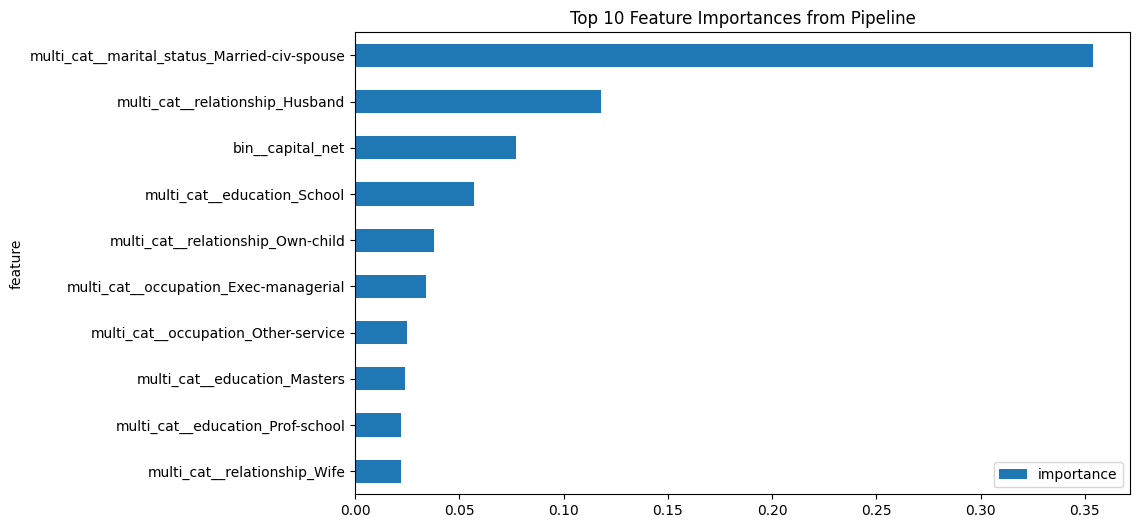

In [53]:
try:
    feature_names = best_xgb_model.named_steps['preprocessor'].get_feature_names_out()
except Exception:
    feature_names = [f'feature_{i}' for i in range(len(best_xgb_model.named_steps['clf'].feature_importances_))]

importances = pd.DataFrame({
    'feature': feature_names,
    'importance': np.round(best_xgb_model.named_steps['clf'].feature_importances_, 3)
})


top_10_importances = importances.sort_values('importance', ascending=False).head(10)

top_10_importances.sort_values('importance', ascending=True).set_index('feature').plot.barh(
    figsize=(10, 6),
    title="Top 10 Feature Importances from Pipeline"
)


## **XGB Classification Report**

In [54]:
y_pred_xgb = best_xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      4945
           1       0.70      0.63      0.66      1568

    accuracy                           0.84      6513
   macro avg       0.79      0.77      0.78      6513
weighted avg       0.84      0.84      0.84      6513



# **Model Comparison**

          Model  Best CV AUC  Test AUC  Test F1 Macro  Test F1 Micro
0  RandomForest     0.897313  0.890358       0.774317       0.842162
1       XGBoost     0.638773  0.892688       0.779937       0.844618
RFC PR AUC: 0.7323, RFC ROC AUC: 0.8904
XGB PR AUC: 0.7374, XGB ROC AUC: 0.8927


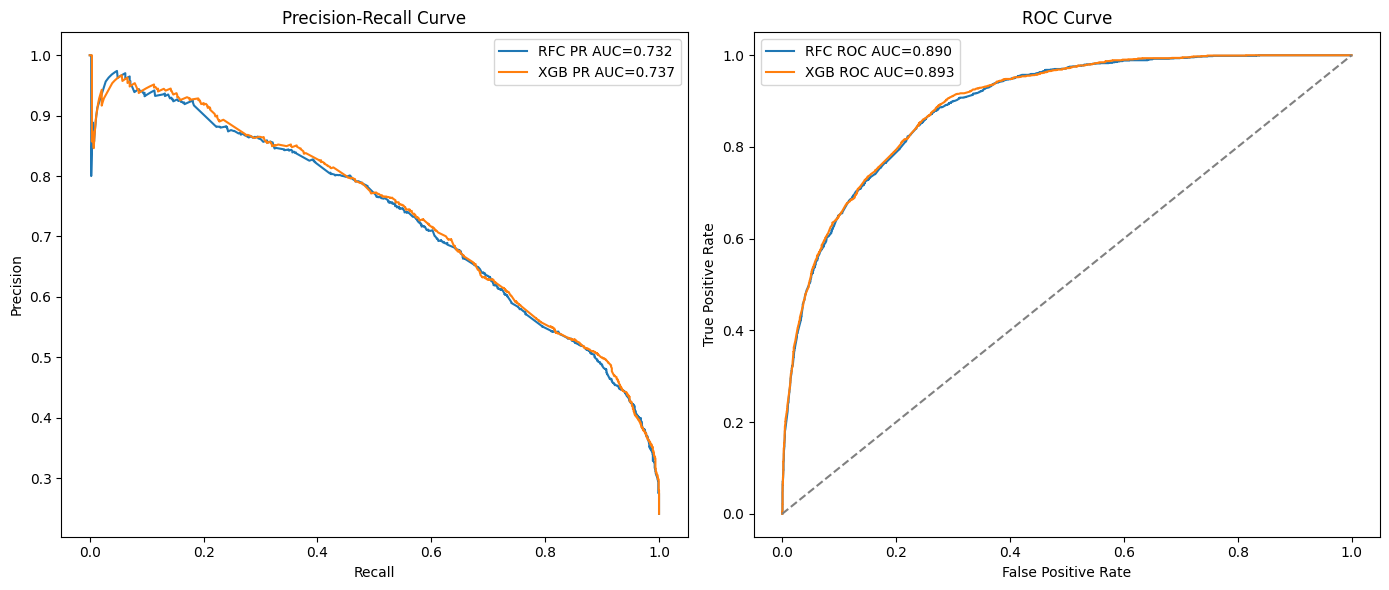


RandomForest class-level precision/recall/f1
         precision    recall        f1
class_0   0.881105  0.915672  0.898056
class_1   0.696507  0.610332  0.650578

XGBoost class-level precision/recall/f1
         precision    recall        f1
class_0   0.885664  0.913246  0.899243
class_1   0.696605  0.628189  0.660630

RandomForest class1 (income >50K) 95% CI: precision=0.696 (0.672-0.719), recall=0.610 (0.586-0.634), f1=0.650 (0.631-0.669)

XGBoost class1 (income >50K) 95% CI: precision=0.696 (0.673-0.721), recall=0.627 (0.604-0.650), f1=0.660 (0.640-0.680)

Primary business metric: Recall (class_1) (Prioritize models w/ higher class_1 recall)


In [55]:
# Model Comparison Table
comparison_data = {
    'Model': ['RandomForest', 'XGBoost'],
    'Best CV AUC': [rfc_grid_search.best_score_, xgb_grid_search.best_score_],
    'Test AUC': [roc_auc_score(y_test, best_rfc_model.predict_proba(X_test)[:, 1]),
                 roc_auc_score(y_test, best_xgb_model.predict_proba(X_test)[:, 1])],
    'Test F1 Macro': [f1_score(y_test, y_pred_rfc, average='macro'),
                      f1_score(y_test, y_pred_xgb, average='macro')],
    'Test F1 Micro': [f1_score(y_test, y_pred_rfc, average='micro'),
                      f1_score(y_test, y_pred_xgb, average='micro')]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)


# Numeric curves and AUC
rfc_scores = best_rfc_model.predict_proba(X_test)[:, 1]
xgb_scores = best_xgb_model.predict_proba(X_test)[:, 1]

rfc_pr_prec, rfc_pr_rec, _ = precision_recall_curve(y_test, rfc_scores)
xgb_pr_prec, xgb_pr_rec, _ = precision_recall_curve(y_test, xgb_scores)

rfc_roc_fpr, rfc_roc_tpr, _ = roc_curve(y_test, rfc_scores)
xgb_roc_fpr, xgb_roc_tpr, _ = roc_curve(y_test, xgb_scores)

rfc_pr_auc = auc(rfc_pr_rec, rfc_pr_prec)
xgb_pr_auc = auc(xgb_pr_rec, xgb_pr_prec)

rfc_roc_auc = auc(rfc_roc_fpr, rfc_roc_tpr)
xgb_roc_auc = auc(xgb_roc_fpr, xgb_roc_tpr)

print(f"RFC PR AUC: {rfc_pr_auc:.4f}, RFC ROC AUC: {rfc_roc_auc:.4f}")
print(f"XGB PR AUC: {xgb_pr_auc:.4f}, XGB ROC AUC: {xgb_roc_auc:.4f}")

plt.figure(figsize=(14, 6))
# Precision-Recall curve
plt.subplot(1, 2, 1)
plt.plot(rfc_pr_rec, rfc_pr_prec, label=f'RFC PR AUC={rfc_pr_auc:.3f}')
plt.plot(xgb_pr_rec, xgb_pr_prec, label=f'XGB PR AUC={xgb_pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

# ROC curve
plt.subplot(1, 2, 2)
plt.plot(rfc_roc_fpr, rfc_roc_tpr, label=f'RFC ROC AUC={rfc_roc_auc:.3f}')
plt.plot(xgb_roc_fpr, xgb_roc_tpr, label=f'XGB ROC AUC={xgb_roc_auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

# Class-level precision/recall/f1
for model_name, y_pred in [('RandomForest', y_pred_rfc), ('XGBoost', y_pred_xgb)]:
    print(f"\n{model_name} class-level precision/recall/f1")
    df_pr = pd.DataFrame({
        'precision': precision_score(y_test, y_pred, average=None),
        'recall': recall_score(y_test, y_pred, average=None),
        'f1': f1_score(y_test, y_pred, average=None)
    }, index=['class_0', 'class_1'])
    print(df_pr)

# 95% bootstrap CI for class 1 (high-income >50K) metrics

def bootstrap_metric(y_true, y_pred, metric_fn, n_bootstrap=1000, random_state=42):
    vals = []
    for seed in range(n_bootstrap):
        rng = np.random.RandomState(random_state + seed)
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        y_true_s = y_true.iloc[idx] if hasattr(y_true, 'iloc') else y_true[idx]
        y_pred_s = y_pred.iloc[idx] if hasattr(y_pred, 'iloc') else y_pred[idx]
        vals.append(metric_fn(y_true_s, y_pred_s))
    return np.percentile(vals, 2.5), np.percentile(vals, 97.5), np.mean(vals)

for model_name, y_pred in [('RandomForest', y_pred_rfc), ('XGBoost', y_pred_xgb)]:
    p_lo, p_hi, p_mean = bootstrap_metric(y_test, pd.Series(y_pred), lambda yt, yp: precision_score(yt, yp, labels=[1], average='binary'))
    r_lo, r_hi, r_mean = bootstrap_metric(y_test, pd.Series(y_pred), lambda yt, yp: recall_score(yt, yp, labels=[1], average='binary'))
    f_lo, f_hi, f_mean = bootstrap_metric(y_test, pd.Series(y_pred), lambda yt, yp: f1_score(yt, yp, labels=[1], average='binary'))
    print(f"\n{model_name} class1 (income >50K) 95% CI: precision={p_mean:.3f} ({p_lo:.3f}-{p_hi:.3f}), recall={r_mean:.3f} ({r_lo:.3f}-{r_hi:.3f}), f1={f_mean:.3f} ({f_lo:.3f}-{f_hi:.3f})")

# Primary business metric
primary_metric = 'Recall (class_1)'  # business goal: identify high-income individuals
print(f"\nPrimary business metric: {primary_metric} (Prioritize models w/ higher class_1 recall)")

# **Conclusions**

This notebook demonstrates a complete machine learning pipeline for predicting income levels using the Adult Census dataset. Key findings:

- The RandomForest model achieved a ROC AUC of approximately **89.04%** on the test set.
- XGBoost performed similarly with a ROC AUC of **89.27%**.
- Top features include marital.status (Married-civ-spouse), capital_net, and relationship (Husband).

**Primary business metric**

- Chosen metric: class_1 recall (high-income, >50K) because the use case emphasizes identifying eligible high-income individuals.
- Deploy decision rule: prioritize model with higher class_1 recall while also maintaining acceptable class_1 F1 to balance precision.
- **XGBoost shows slightly better performance on class_1 recall (0.628) compared to RandomForest (0.610), making it marginally preferable for this business objective.**

**Rollout threshold recommendation**

- Establish a minimum acceptable class_1 recall threshold (e.g., >0.75) before production deployment.
- Use model gating: if candidate model meets class_1 recall + F1 thresholds, proceed to A/B rollout; otherwise continue tuning.

**Next Steps**

- Deploy the model for real-time predictions.

In [50]:
# if __name__ == '__main__':
#     import joblib

#     joblib.dump(best_rfc_model, 'random_forest_model.pkl')
#     joblib.dump(best_xgb_model, 'xgboost_model.pkl')
#     print("Models saved.")